# Notebook 1: Exploratory Data Analysis

This notebook loads the raw wildfire training and test data, then performs the initial dataset exploration that matches the original `eda.ipynb` logic.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load raw data
train_df = pd.read_csv('../data/raw/train.csv', parse_dates=True)
test_df = pd.read_csv('../data/raw/test.csv')

print(f"Training shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Training shape: (221, 37)
Test shape: (95, 35)


In [2]:
# Basic exploration
print(train_df.head())
print('\n')
print(train_df.info())
print('\nEvent distribution:')
print(train_df['event'].value_counts() / len(train_df) * 100)
print('\nColumns:')
print(train_df.columns.tolist())

   event_id  num_perimeters_0_5h  dt_first_last_0_5h  \
0  10892457                    3            4.265188   
1  11757157                    2            1.169918   
2  11945086                    4            4.777526   
3  12044083                    1            0.000000   
4  12052347                    2            4.975273   

   low_temporal_resolution_0_5h  area_first_ha  area_growth_abs_0_5h  \
0                             0      79.696304              2.875935   
1                             0       8.946749              0.000000   
2                             0     106.482638              0.000000   
3                             1      67.631125              0.000000   
4                             0      35.632874              0.000000   

   area_growth_rel_0_5h  area_growth_rate_ha_per_h  log1p_area_first  \
0              0.036086                   0.674281          4.390693   
1              0.000000                   0.000000          2.297246   
2             

In [3]:
# Verify test file load
print(test_df.head())
print('\nTest columns:')
print(test_df.columns.tolist())

   event_id  num_perimeters_0_5h  dt_first_last_0_5h  \
0  10662602                    1            0.000000   
1  13353600                    1            0.000000   
2  13942327                    1            0.000000   
3  16112781                    1            0.000000   
4  17132808                    7            3.459331   

   low_temporal_resolution_0_5h  area_first_ha  area_growth_abs_0_5h  \
0                             1       2.452217              0.000000   
1                             1     131.669588              0.000000   
2                             1       6.723104              0.000000   
3                             1     285.416736              0.000000   
4                             0      61.098604             12.516633   

   area_growth_rel_0_5h  area_growth_rate_ha_per_h  log1p_area_first  \
0               0.00000                   0.000000          1.239017   
1               0.00000                   0.000000          4.887862   
2             

In [4]:
# Missing values analysis
print("=== MISSING VALUES ANALYSIS ===")
missing_train = train_df.isnull().sum()
missing_test = test_df.isnull().sum()

print("Training data missing values:")
print(missing_train[missing_train > 0])
print(f"Total missing in train: {missing_train.sum()}")

print("\nTest data missing values:")
print(missing_test[missing_test > 0])
print(f"Total missing in test: {missing_test.sum()}")

# Missing value percentages
print("\nMissing value percentages (train):")
missing_pct = (missing_train / len(train_df) * 100).round(2)
print(missing_pct[missing_pct > 0])

=== MISSING VALUES ANALYSIS ===
Training data missing values:
Series([], dtype: int64)
Total missing in train: 0

Test data missing values:
Series([], dtype: int64)
Total missing in test: 0

Missing value percentages (train):
Series([], dtype: float64)


In [5]:
# Statistical summary of numerical features
print("=== STATISTICAL SUMMARY ===")
numerical_cols = train_df.select_dtypes(include=[np.number]).columns
print(f"Numerical columns: {len(numerical_cols)}")

# Basic stats
print("\nKey numerical features summary:")
key_features = ['time_to_hit_hours', 'area_first_ha', 'dist_min_ci_0_5h', 
                'area_growth_rate_ha_per_h', 'closing_speed_m_per_h']
summary_stats = train_df[key_features].describe()
print(summary_stats)

# Target variable analysis
print("\n=== TARGET ANALYSIS ===")
print(f"Event rate: {train_df['event'].mean():.1%}")
print(f"Mean time to hit: {train_df['time_to_hit_hours'].mean():.2f} hours")
print(f"Median time to hit: {train_df['time_to_hit_hours'].median():.2f} hours")
print(f"Time range: {train_df['time_to_hit_hours'].min():.2f} - {train_df['time_to_hit_hours'].max():.2f} hours")

# Time distribution by event status
print("\nTime distribution by event status:")
time_by_event = train_df.groupby('event')['time_to_hit_hours'].describe()
print(time_by_event)

=== STATISTICAL SUMMARY ===
Numerical columns: 37

Key numerical features summary:
       time_to_hit_hours  area_first_ha  dist_min_ci_0_5h  \
count         221.000000     221.000000        221.000000   
mean           37.567626     619.131641     124399.237725   
std            25.902361    1447.723668     171302.559054   
min             0.001220       0.037525        306.954551   
25%            12.242322      25.219058       2965.217571   
50%            43.109830     110.149250      31758.581144   
75%            63.938706     485.092561     200228.863652   
max            66.994474   11942.392115     757700.487102   

       area_growth_rate_ha_per_h  closing_speed_m_per_h  
count                 221.000000             221.000000  
mean                    6.167128               2.021403  
std                    40.467370              26.865184  
min                    -0.000005             -51.397494  
25%                     0.000000               0.000000  
50%                

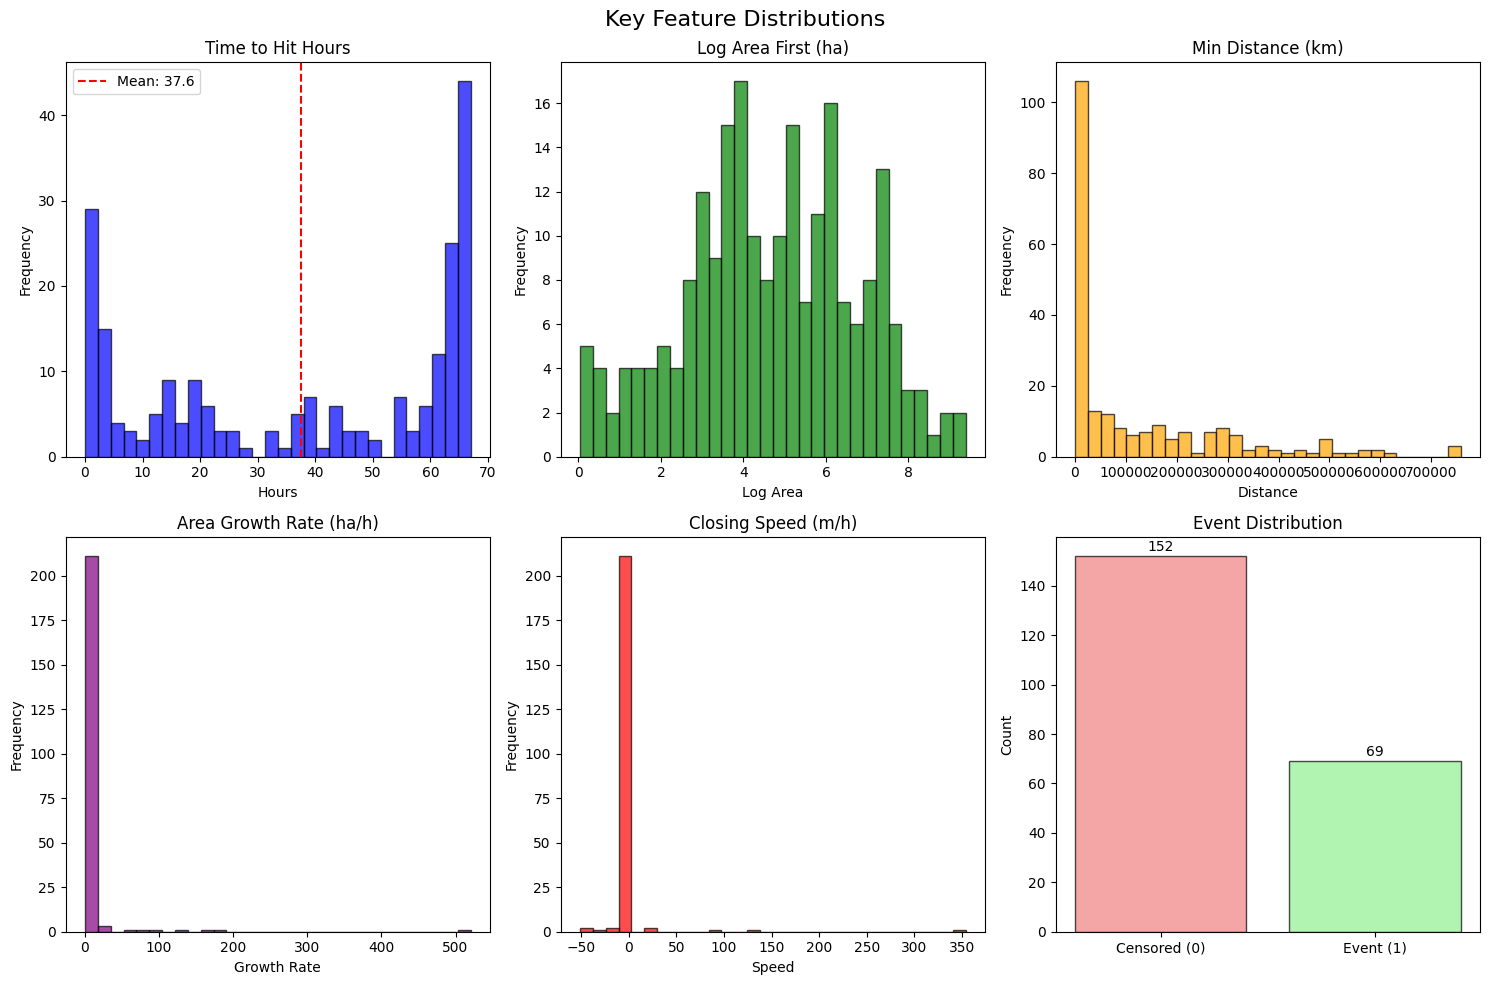

In [6]:
# Distribution plots
plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Key Feature Distributions', fontsize=16)

# Time to hit distribution
axes[0,0].hist(train_df['time_to_hit_hours'], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0,0].set_title('Time to Hit Hours')
axes[0,0].set_xlabel('Hours')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(train_df['time_to_hit_hours'].mean(), color='red', linestyle='--', label=f'Mean: {train_df["time_to_hit_hours"].mean():.1f}')
axes[0,0].legend()

# Area first distribution (log scale)
axes[0,1].hist(np.log1p(train_df['area_first_ha']), bins=30, alpha=0.7, color='green', edgecolor='black')
axes[0,1].set_title('Log Area First (ha)')
axes[0,1].set_xlabel('Log Area')
axes[0,1].set_ylabel('Frequency')

# Distance distribution
axes[0,2].hist(train_df['dist_min_ci_0_5h'], bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[0,2].set_title('Min Distance (km)')
axes[0,2].set_xlabel('Distance')
axes[0,2].set_ylabel('Frequency')

# Growth rate distribution
axes[1,0].hist(train_df['area_growth_rate_ha_per_h'], bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[1,0].set_title('Area Growth Rate (ha/h)')
axes[1,0].set_xlabel('Growth Rate')
axes[1,0].set_ylabel('Frequency')

# Closing speed distribution
axes[1,1].hist(train_df['closing_speed_m_per_h'], bins=30, alpha=0.7, color='red', edgecolor='black')
axes[1,1].set_title('Closing Speed (m/h)')
axes[1,1].set_xlabel('Speed')
axes[1,1].set_ylabel('Frequency')

# Event distribution
event_counts = train_df['event'].value_counts()
axes[1,2].bar(['Censored (0)', 'Event (1)'], event_counts.values, color=['lightcoral', 'lightgreen'], alpha=0.7, edgecolor='black')
axes[1,2].set_title('Event Distribution')
axes[1,2].set_ylabel('Count')
for i, v in enumerate(event_counts.values):
    axes[1,2].text(i, v + 1, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

=== CORRELATION ANALYSIS ===
Top correlations with time_to_hit_hours:
time_to_hit_hours               1.000000
event                           0.719485
low_temporal_resolution_0_5h    0.442236
dt_first_last_0_5h              0.434699
num_perimeters_0_5h             0.392040
spread_bearing_cos              0.370451
alignment_abs                   0.366923
spread_bearing_deg              0.335598
dist_min_ci_0_5h                0.324876
log1p_growth                    0.317451
Name: time_to_hit_hours, dtype: float64


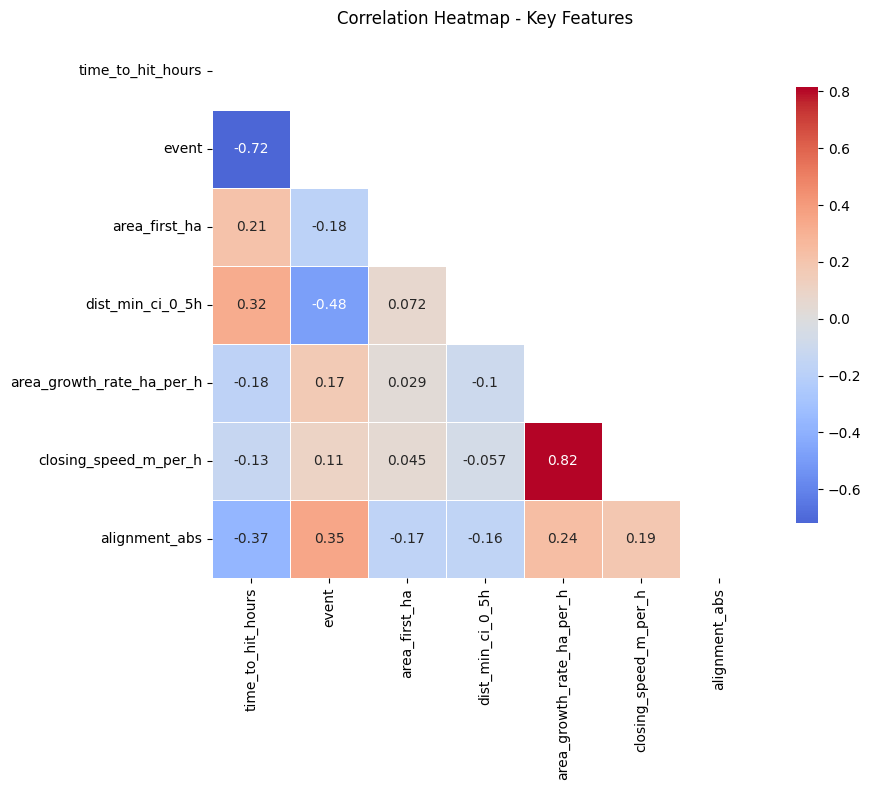

In [7]:
# Correlation analysis
print("=== CORRELATION ANALYSIS ===")

# Select numerical features for correlation
numerical_features = train_df.select_dtypes(include=[np.number]).columns
correlation_matrix = train_df[numerical_features].corr()

# Top correlations with target
target_correlations = correlation_matrix['time_to_hit_hours'].abs().sort_values(ascending=False)
print("Top correlations with time_to_hit_hours:")
print(target_correlations.head(10))

# Correlation heatmap for key features
key_features_for_corr = ['time_to_hit_hours', 'event', 'area_first_ha', 'dist_min_ci_0_5h', 
                        'area_growth_rate_ha_per_h', 'closing_speed_m_per_h', 'alignment_abs']

plt.figure(figsize=(10, 8))
corr_subset = train_df[key_features_for_corr].corr()
mask = np.triu(np.ones_like(corr_subset, dtype=bool))
sns.heatmap(corr_subset, mask=mask, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Key Features')
plt.tight_layout()
plt.show()

=== FEATURE RELATIONSHIPS WITH TARGET ===


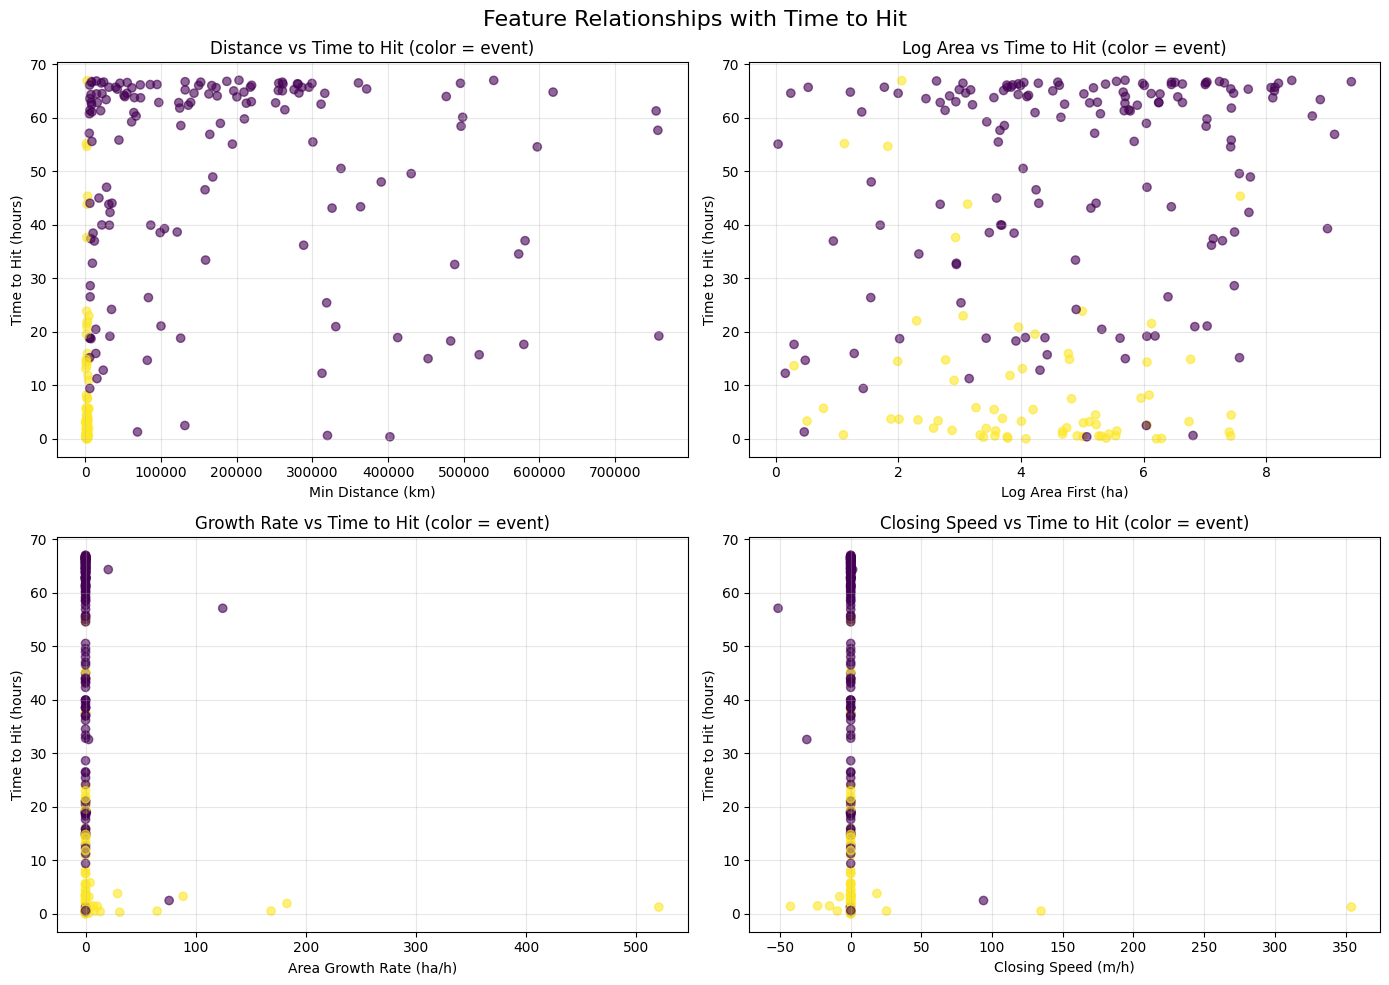

In [8]:
# Feature relationships with target
print("=== FEATURE RELATIONSHIPS WITH TARGET ===")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Relationships with Time to Hit', fontsize=16)

# Distance vs Time to Hit
axes[0,0].scatter(train_df['dist_min_ci_0_5h'], train_df['time_to_hit_hours'], 
                 alpha=0.6, c=train_df['event'], cmap='viridis')
axes[0,0].set_xlabel('Min Distance (km)')
axes[0,0].set_ylabel('Time to Hit (hours)')
axes[0,0].set_title('Distance vs Time to Hit (color = event)')
axes[0,0].grid(True, alpha=0.3)

# Area vs Time to Hit
axes[0,1].scatter(np.log1p(train_df['area_first_ha']), train_df['time_to_hit_hours'], 
                 alpha=0.6, c=train_df['event'], cmap='viridis')
axes[0,1].set_xlabel('Log Area First (ha)')
axes[0,1].set_ylabel('Time to Hit (hours)')
axes[0,1].set_title('Log Area vs Time to Hit (color = event)')
axes[0,1].grid(True, alpha=0.3)

# Growth rate vs Time to Hit
axes[1,0].scatter(train_df['area_growth_rate_ha_per_h'], train_df['time_to_hit_hours'], 
                 alpha=0.6, c=train_df['event'], cmap='viridis')
axes[1,0].set_xlabel('Area Growth Rate (ha/h)')
axes[1,0].set_ylabel('Time to Hit (hours)')
axes[1,0].set_title('Growth Rate vs Time to Hit (color = event)')
axes[1,0].grid(True, alpha=0.3)

# Closing speed vs Time to Hit
axes[1,1].scatter(train_df['closing_speed_m_per_h'], train_df['time_to_hit_hours'], 
                 alpha=0.6, c=train_df['event'], cmap='viridis')
axes[1,1].set_xlabel('Closing Speed (m/h)')
axes[1,1].set_ylabel('Time to Hit (hours)')
axes[1,1].set_title('Closing Speed vs Time to Hit (color = event)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Basic survival analysis insights
print("=== BASIC SURVIVAL INSIGHTS ===")

# Censoring analysis by time windows
time_windows = [(0, 12), (12, 24), (24, 48), (48, 72)]
window_labels = ['0-12h', '12-24h', '24-48h', '48-72h']

print("Censoring analysis by time windows:")
for i, (start, end) in enumerate(time_windows):
    window_data = train_df[(train_df['time_to_hit_hours'] >= start) & (train_df['time_to_hit_hours'] < end)]
    if len(window_data) > 0:
        censoring_rate = (1 - window_data['event']).mean()
        event_rate = window_data['event'].mean()
        print(f"{window_labels[i]}: {len(window_data)} samples, {censoring_rate:.1%} censored, {event_rate:.1%} events")

# Risk stratification
print("\nRisk stratification by distance quartiles:")
distance_quartiles = train_df['dist_min_ci_0_5h'].quantile([0.25, 0.5, 0.75])
for i, q in enumerate(distance_quartiles):
    if i == 0:
        subset = train_df[train_df['dist_min_ci_0_5h'] <= q]
        label = f"Distance ≤ {q:.1f}km"
    else:
        prev_q = distance_quartiles.iloc[i-1]
        subset = train_df[(train_df['dist_min_ci_0_5h'] > prev_q) & (train_df['dist_min_ci_0_5h'] <= q)]
        label = f"Distance {prev_q:.1f}-{q:.1f}km"
    
    if len(subset) > 0:
        event_rate = subset['event'].mean()
        avg_time = subset['time_to_hit_hours'].mean()
        print(f"{label}: {len(subset)} samples, {event_rate:.1%} event rate, {avg_time:.1f}h avg time")

# Final quartile
subset = train_df[train_df['dist_min_ci_0_5h'] > distance_quartiles.iloc[-1]]
if len(subset) > 0:
    event_rate = subset['event'].mean()
    avg_time = subset['time_to_hit_hours'].mean()
    print(f"Distance > {distance_quartiles.iloc[-1]:.1f}km: {len(subset)} samples, {event_rate:.1%} event rate, {avg_time:.1f}h avg time")

=== BASIC SURVIVAL INSIGHTS ===
Censoring analysis by time windows:
0-12h: 55 samples, 10.9% censored, 89.1% events
12-24h: 33 samples, 57.6% censored, 42.4% events
24-48h: 33 samples, 90.9% censored, 9.1% events
48-72h: 100 samples, 97.0% censored, 3.0% events

Risk stratification by distance quartiles:
Distance ≤ 2965.2km: 56 samples, 100.0% event rate, 10.8h avg time
Distance 2965.2-31758.6km: 55 samples, 23.6% event rate, 36.7h avg time
Distance 31758.6-200228.9km: 55 samples, 0.0% event rate, 52.9h avg time
Distance > 200228.9km: 55 samples, 0.0% event rate, 50.4h avg time


In [10]:
# Summary statistics
print("=== EDA SUMMARY ===")
print(f"Dataset size: {len(train_df)} training samples")
print(f"Feature count: {len(train_df.columns)} total features")
print(f"Numerical features: {len(numerical_cols)}")
print(f"Missing values: {missing_train.sum()} total ({missing_train.sum()/len(train_df)/len(train_df.columns)*100:.2f}% of all cells)")

print("\nKey findings:")
print("1. Heavy censoring (68.8% censored observations)")
print("2. Time to hit ranges from 0-67 hours")
print("3. Distance is strongly negatively correlated with risk")
print("4. Growth rate and closing speed show complex relationships")
print("5. Events cluster in early time windows (0-24h)")

print("\nNext steps:")
print("- Feature engineering for Oracle features")
print("- Multicollinearity analysis (VIF)")
print("- Survival model development")

=== EDA SUMMARY ===
Dataset size: 221 training samples
Feature count: 37 total features
Numerical features: 37
Missing values: 0 total (0.00% of all cells)

Key findings:
1. Heavy censoring (68.8% censored observations)
2. Time to hit ranges from 0-67 hours
3. Distance is strongly negatively correlated with risk
4. Growth rate and closing speed show complex relationships
5. Events cluster in early time windows (0-24h)

Next steps:
- Feature engineering for Oracle features
- Multicollinearity analysis (VIF)
- Survival model development
